In [1]:
# For windows
# !pip install torch==2.6.0+cu126 torchvision==0.21.0+cu126 torchaudio==2.6.0 --index-url https://download.pytorch.org/whl/cu126
# !pip install transformers matplotlib
# !pip install timm

In [2]:
from PIL import Image
from transformers import pipeline
from collections import Counter
import matplotlib.pyplot as plt
from IPython.display import Audio as IPythonAudio
import torch
import numpy as np
import os
import warnings
from transformers.utils import logging

D:\dev\AI_Enablement\assignment\1\AI-Enablement-main\image-narration\.env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "true"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")
logging.set_verbosity_error()

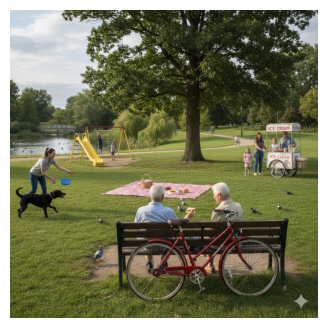

In [4]:
img = Image.open("images/image-test.png")

plt.figure(figsize=(6, 4))
plt.imshow(img)
plt.axis('off')
plt.show()

In [5]:
object_detection = pipeline(
    task="object-detection",
    model="facebook/detr-resnet-50",
)

detections = object_detection(img)

print(detections)

Loading weights: 100%|██████████████████████████████████████| 530/530 [00:01<00:00, 514.80it/s, Materializing param=model.query_position_embeddings.weight]


[{'score': 0.5343373417854309, 'label': 'bird', 'box': {'xmin': 72, 'ymin': 461, 'xmax': 88, 'ymax': 478}}, {'score': 0.994300127029419, 'label': 'bird', 'box': {'xmin': 273, 'ymin': 783, 'xmax': 311, 'ymax': 841}}, {'score': 0.9126651287078857, 'label': 'bird', 'box': {'xmin': 288, 'ymin': 694, 'xmax': 311, 'ymax': 712}}, {'score': 0.9935193657875061, 'label': 'bird', 'box': {'xmin': 800, 'ymin': 653, 'xmax': 837, 'ymax': 682}}, {'score': 0.9962066411972046, 'label': 'dog', 'box': {'xmin': 19, 'ymin': 595, 'xmax': 185, 'ymax': 693}}, {'score': 0.6389688849449158, 'label': 'bicycle', 'box': {'xmin': 744, 'ymin': 428, 'xmax': 765, 'ymax': 453}}, {'score': 0.5952640771865845, 'label': 'bird', 'box': {'xmin': 38, 'ymin': 459, 'xmax': 54, 'ymax': 476}}, {'score': 0.9827331304550171, 'label': 'bird', 'box': {'xmin': 557, 'ymin': 643, 'xmax': 580, 'ymax': 671}}, {'score': 0.7833458781242371, 'label': 'bird', 'box': {'xmin': 555, 'ymin': 592, 'xmax': 591, 'ymax': 610}}, {'score': 0.9742893576

In [8]:
filtered = [
    d["label"]
    for d in detections
    if d["score"] >= 0.7
]
counts = Counter(filtered)
print("Counts:", counts)

Counts: Counter({'person': 13, 'bird': 9, 'bicycle': 3, 'dog': 1, 'bench': 1, 'frisbee': 1})


In [9]:
def pluralize(word, count):
    if count == 1:
        return f"1 {word}"
    else:
        if word.endswith('s'):
            return f"{count} {word}es"
        else:
            return f"{count} {word}s"


def counts_to_sentence(counts):
    if not counts:
        return "No recognizable objects were detected in the image."

    parts = [pluralize(label, count) for label, count in counts.items()]

    if len(parts) == 1:
        return f"The image contains {parts[0]}."

    if len(parts) == 2:
        return f"The image contains {parts[0]} and {parts[1]}."

    return f"The image contains {', '.join(parts[:-1])}, and {parts[-1]}."

sentence = counts_to_sentence(counts)
print(sentence)

The image contains 9 birds, 1 dog, 3 bicycles, 13 persons, 1 bench, and 1 frisbee.


In [10]:
narrator = pipeline(
    task="text-to-audio",
    model="suno/bark-small"
)

narrated_text = narrator(sentence)
sampling_rate = narrated_text["sampling_rate"]
audio = np.array(narrated_text["audio"])
if audio.ndim == 2:
    audio = audio.squeeze(0)

print(f"Shape: {audio.shape}, Sampling Rate: {sampling_rate}")

Loading weights: 100%|███████████████████████████████████████| 542/542 [00:00<00:00, 886.04it/s, Materializing param=semantic.position_embeds_layer.weight]


Shape: (171200,), Sampling Rate: 24000


In [11]:
IPythonAudio(audio, rate=sampling_rate)